# 08 — BridgeDb metabolite mapping: before vs after

This notebook documents and evaluates the addition of **BridgeDb metabolite ID mapping** to the
GPML → RDF conversion, and discusses the risks (overwrite, stereochemistry conflation, idempotency).

## Root cause of the previously missing mappings
`org.wikipathways.wp2rdf.CreateRDF` (in `tools/gpml2rdf-4.0.4-SNAPSHOT.jar`) loads BridgeDb config from a
**fixed path**, `/tmp/OPSBRIDGEDB/config.properties`, and reads the key `bridgefiles` (a directory of
`*.bridge` databases). If that folder is missing it logs `WARN: BridgeDb config file folder does not exist:`
and **skips metabolite mapping silently** — which is exactly what happened in earlier conversions.
See [`../bridgedb/README.md`](../bridgedb/README.md) for the download + setup + run steps.

## What the mapping adds
For each `wp:Metabolite` the mapper emits BridgeDb-derived cross-references as dedicated `wp:bdb*`
predicates **in addition to** the source identifier (it does not overwrite it):
`wp:bdbChEBI`, `wp:bdbHmdb`, `wp:bdbWikidata`, `wp:bdbPubChem`, `wp:bdbKeggCompound`, `wp:bdbLipidMaps`,
`wp:bdbChemspider`, `wp:bdbInChIKey`.

Mapping DB: `metabolites_20260102.bridge` (figshare DOI 10.6084/m9.figshare.30993322; HMDB Jan 2026,
ChEBI 247, Wikidata 2 Jan 2026).


## Setup
Run the BEFORE cells against the current pathways graph. For the AFTER comparison, load the **new**
conversion output into a second named graph (default `.../graph/pathways-bridgedb`):
```bash
# after `make -B -k -j 12 rdf` with BridgeDb enabled, aggregate + load, e.g.:
isql-vt ... exec="DB.DBA.TTLP(file_to_string_output('all_pathways_bridgedb.ttl'),'',
  'http://rdf-plantmetwiki.bioinformatics.nl/graph/pathways-bridgedb')"
```


In [21]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

ENDPOINT = 'http://localhost:8890/sparql'
G_BEFORE = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/pathways'            # current (no BridgeDb)
G_AFTER  = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/pathways-bridgedb'   # load the NEW conversion here
WP = 'http://vocabularies.wikipathways.org/wp#'

PRE = ('PREFIX wp: <http://vocabularies.wikipathways.org/wp#> '
       'PREFIX dc: <http://purl.org/dc/elements/1.1/> '
       'PREFIX dcterms: <http://purl.org/dc/terms/> '
       'PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> ')

def sparql(q, timeout=180):
    sw = SPARQLWrapper(ENDPOINT); sw.setReturnFormat(JSON); sw.setTimeout(timeout)
    sw.setQuery(PRE + q)
    rows = sw.query().convert()['results']['bindings']
    return pd.DataFrame([{k: v['value'] for k, v in r.items()} for r in rows])

def graph_has_data(g):
    try:
        n = int(sparql(f'SELECT (COUNT(*) AS ?n) WHERE {{ GRAPH <{g}> {{ ?s ?p ?o }} }}')['n'][0])
        return n > 0
    except Exception:
        return False

print('BEFORE graph populated:', graph_has_data(G_BEFORE))
print('AFTER  graph populated:', graph_has_data(G_AFTER), '(load the new conversion to enable the comparison)')


BEFORE graph populated: True
AFTER  graph populated: True (load the new conversion to enable the comparison)


## 1. BridgeDb cross-reference coverage per graph
Counts distinct `wp:Metabolite` nodes carrying each `wp:bdb*` predicate. BEFORE should be ~0.


In [22]:
def bdb_coverage(graph):
    """Distinct wp:Metabolite carrying each wp:bdb* predicate in `graph`.
    Always returns columns ['predicate', 'n_metabolites'] (empty frame if none),
    so downstream merges never KeyError on an all-zero graph."""
    empty = pd.DataFrame(columns=['predicate', 'n_metabolites'])
    if not graph_has_data(graph):
        return empty
    df = sparql(f"""
    SELECT ?p (COUNT(DISTINCT ?m) AS ?n_metabolites) WHERE {{
      GRAPH <{graph}> {{
        ?m a wp:Metabolite ; ?p ?o .
        FILTER(STRSTARTS(STR(?p), "{WP}bdb"))
      }}
    }} GROUP BY ?p ORDER BY DESC(?n_metabolites)""")
    if df.empty or 'p' not in df.columns:
        return empty
    df['predicate'] = df['p'].str.replace(WP, 'wp:', regex=False)
    df['n_metabolites'] = df['n_metabolites'].astype(int)
    return df[['predicate', 'n_metabolites']]

# BridgeDb mapping is ADDITIVE: wp:bdb* predicates are separate from the source
# dc:identifier, so the "before" (no bdb) and "after" (bdb added) states coexist
# inside the single AFTER graph. The old graph is only needed for the literal
# 0-baseline, which is 0 by construction.
n_meta = int(sparql(f'SELECT (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{G_AFTER}> {{ ?m a wp:Metabolite }} }}')['n'][0])
print(f'Total wp:Metabolite nodes (AFTER graph): {n_meta:,}')

cov_after  = bdb_coverage(G_AFTER)
cov_before = bdb_coverage(G_BEFORE)   # optional literal baseline (all zeros)

print('\nBridgeDb cross-reference coverage (AFTER graph):')
print(cov_after.to_string(index=False) if not cov_after.empty else '  (AFTER graph not loaded yet)')

if not cov_after.empty:
    delta = cov_after.merge(cov_before, on='predicate', how='left', suffixes=('_after', '_before'))
    delta = delta.rename(columns={'n_metabolites_after': 'after', 'n_metabolites_before': 'before'})
    delta['before'] = delta['before'].fillna(0).astype(int)
    delta['added']  = delta['after'] - delta['before']
    print('\nBefore vs after (distinct metabolites per cross-reference):')
    print(delta[['predicate', 'before', 'after', 'added']].to_string(index=False))

    n_any = int(sparql(f"""SELECT (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{G_AFTER}> {{
      ?m a wp:Metabolite ; ?p ?o . FILTER(STRSTARTS(STR(?p), "{WP}bdb")) }} }}""")['n'][0])
    print(f'\nMetabolites with >=1 BridgeDb cross-reference: {n_any:,} / {n_meta:,} ({100*n_any/n_meta:.1f}%)')


Total wp:Metabolite nodes (AFTER graph): 4,577

BridgeDb cross-reference coverage (AFTER graph):
         predicate  n_metabolites
    wp:bdbWikidata           3059
    wp:bdbInChIKey           2968
     wp:bdbPubChem           2926
       wp:bdbChEBI           2805
  wp:bdbChemspider           2317
wp:bdbKeggCompound           1120
        wp:bdbHmdb            975
   wp:bdbLipidMaps            510

Before vs after (distinct metabolites per cross-reference):
         predicate  before  after  added
    wp:bdbWikidata       0   3059   3059
    wp:bdbInChIKey       0   2968   2968
     wp:bdbPubChem       0   2926   2926
       wp:bdbChEBI       0   2805   2805
  wp:bdbChemspider       0   2317   2317
wp:bdbKeggCompound       0   1120   1120
        wp:bdbHmdb       0    975    975
   wp:bdbLipidMaps       0    510    510

Metabolites with >=1 BridgeDb cross-reference: 3,198 / 4,577 (69.9%)


## Figure — from source identifiers (Fig 5) to BridgeDb-resolved cross-references

This figure builds on Figure 5 (notebook 05) and integrates what BridgeDb adds.

**Figure X. Direct metabolite mapping via BridgeDb complements query-time federation.** 
**(A)** How the 4,577 `wp:Metabolite` nodes resolve to external chemical databases: 3,198 (69.9%) now 
carry at least one BridgeDb-materialised cross-reference and are resolvable *in-graph without federation* 
(orange); 1,207 (26.4%) carry only an InChIKey and remain reachable through query-time federation (blue); 
172 (3.8%) have neither. **(B)** Cross-reference coverage per database, comparing the single PlantCyc 
source identifier each metabolite carries (blue) with the BridgeDb-added `wp:bdb*` cross-references 
(orange). PlantCyc supplies mostly a lone InChIKey with few direct database links (ChEBI 174, PubChem 75, 
KEGG 43); BridgeDb (build 20260102: HMDB, ChEBI, Wikidata) raises these to 2,805 ChEBI, 2,926 PubChem and 
1,120 KEGG and adds Wikidata (3,059), ChemSpider (2,317), HMDB (975) and LipidMaps (510) links absent from 
the source. Most directly-mapped metabolites become multi-database hubs (the majority link to ≥4 
databases). MetaNetX is not in the BridgeDb metabolite build and stays source-only. Mappings are added 
under separate predicates and never overwrite the curated identifier.

*Complementarity:* BridgeDb resolves the common chemical databases directly in the graph (fast, offline, 
no live query), while InChIKey-based federation reaches **beyond** this fixed set into the wider Linked 
Open Data cloud — e.g. Wikidata biological-role, taxonomic and pharmacological facts, and any 
InChIKey-bearing resource — including knowledge that lives outside PlantMetWiki. The two together give 
both materialised interoperability and open-ended reach.


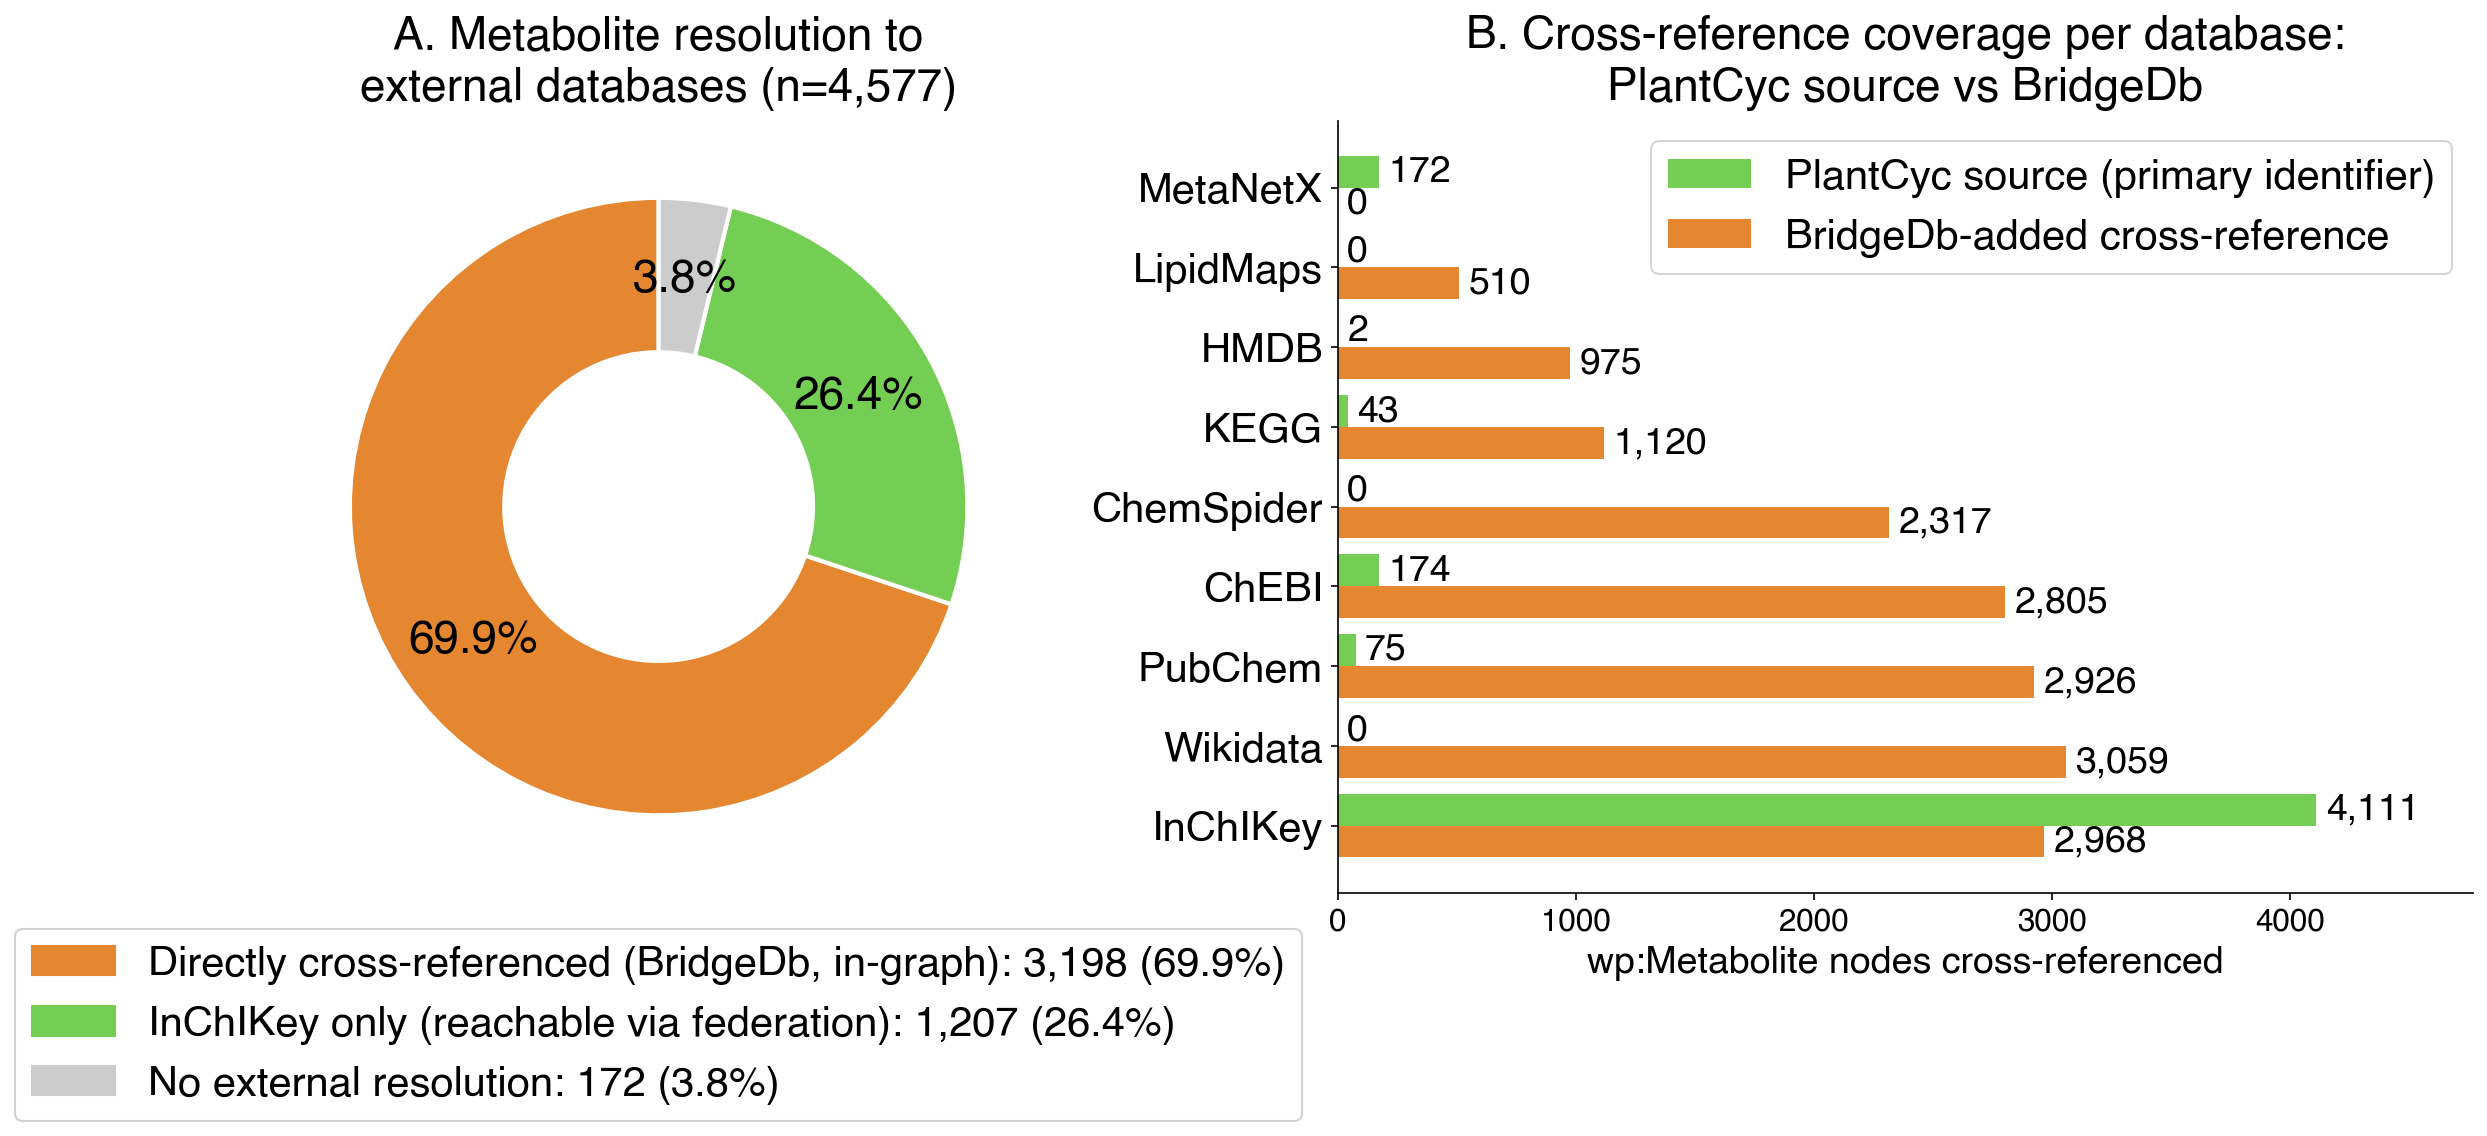

Resolution: direct(BridgeDb)=3,198 (69.9%), federation-only=1,207 (26.4%), neither=172 (3.8%)
Of the 3,198 directly-mapped metabolites, 2,732 (85%) link to >=4 databases.
PlantCyc source (primary): {'Wikidata': 0, 'ChEBI': 174, 'PubChem': 75, 'ChemSpider': 0, 'KEGG': 43, 'HMDB': 2, 'LipidMaps': 0, 'MetaNetX': 172, 'InChIKey': 4111}
BridgeDb-added           : {'Wikidata': 3059, 'ChEBI': 2805, 'PubChem': 2926, 'ChemSpider': 2317, 'KEGG': 1120, 'HMDB': 975, 'LipidMaps': 510, 'MetaNetX': 0, 'InChIKey': 2968}


In [39]:
# -- Figure: from source identifiers (Fig 5) to BridgeDb-resolved cross-references
# Panel A: how metabolites resolve to external DBs (direct via BridgeDb vs federation)
# Panel B: per-database coverage, PlantCyc source vs BridgeDb-added
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
plt.rcParams.update({'figure.dpi': 150, 'font.size': 15,
                     'font.family': 'sans-serif',
                     'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans']})

# Explicit bdb predicate list (VALUES) — far faster than STRSTARTS/NOT EXISTS on Virtuoso
BDB_VALUES = ('VALUES ?p { wp:bdbWikidata wp:bdbChEBI wp:bdbPubChem wp:bdbChemspider '
              'wp:bdbKeggCompound wp:bdbHmdb wp:bdbLipidMaps wp:bdbInChIKey }')

n_total    = int(sparql(f'SELECT (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{G_AFTER}> {{ ?m a wp:Metabolite }} }}')['n'][0])
n_direct   = int(sparql(f'SELECT (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{G_AFTER}> {{ ?m a wp:Metabolite ; ?p ?o . {BDB_VALUES} }} }}')['n'][0])
n_inchikey = int(sparql(f'SELECT (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{G_AFTER}> {{ ?m a wp:Metabolite ; dc:source "InChIKey" }} }}')['n'][0])
n_ink_bdb  = int(sparql(f'SELECT (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{G_AFTER}> {{ ?m a wp:Metabolite ; dc:source "InChIKey" ; ?p ?o . {BDB_VALUES} }} }}')['n'][0])
n_fed      = n_inchikey - n_ink_bdb          # InChIKey-only, reachable via federation
n_neither  = n_total - n_direct - n_fed

# ---- Panel B data ----
DBS = ['Wikidata', 'ChEBI', 'PubChem', 'ChemSpider', 'KEGG', 'HMDB', 'LipidMaps', 'MetaNetX', 'InChIKey']
src_map = {'InChIKey': 'InChIKey', 'ChEBI': 'ChEBI', 'MetaNetX': 'MetaNetX',
           'PubChem-compound': 'PubChem', 'KEGG Compound': 'KEGG', 'HMDB': 'HMDB'}
src_counts = {d: 0 for d in DBS}
for _, r in sparql(f'SELECT ?src (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{G_AFTER}> {{ ?m a wp:Metabolite ; dc:source ?src }} }} GROUP BY ?src').iterrows():
    if src_map.get(r['src']):
        src_counts[src_map[r['src']]] = int(r['n'])
bdb_map = {'bdbWikidata': 'Wikidata', 'bdbChEBI': 'ChEBI', 'bdbPubChem': 'PubChem',
           'bdbChemspider': 'ChemSpider', 'bdbKeggCompound': 'KEGG', 'bdbHmdb': 'HMDB',
           'bdbLipidMaps': 'LipidMaps', 'bdbInChIKey': 'InChIKey'}
bdb_counts = {d: 0 for d in DBS}
for _, r in bdb_coverage(G_AFTER).iterrows():
    if bdb_map.get(r['predicate'].replace('wp:', '')):
        bdb_counts[bdb_map[r['predicate'].replace('wp:', '')]] = int(r['n_metabolites'])

order = sorted(DBS, key=lambda d: -(bdb_counts[d] + src_counts[d]))
y = np.arange(len(order))
src_vals = [src_counts[d] for d in order]
bdb_vals = [bdb_counts[d] for d in order]

# ---- Figure ----
fig, (axA, axB) = plt.subplots(1, 2, figsize=(17, 8), gridspec_kw={'width_ratios': [1, 1.45]})

# Panel A — resolution mode donut
cats = [('Directly cross-referenced (BridgeDb, in-graph)', n_direct, '#e48730'),
        ('InChIKey only (reachable via federation)',       n_fed,    '#75CE54'),
        ('No external resolution',                         n_neither, '#cccccc')]
labels, vals, colors = zip(*cats)
wedges, _t, auto = axA.pie(vals, colors=colors, labels=None, autopct='%1.1f%%', startangle=90,
                           wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2), pctdistance=0.74)
for a in auto:
    a.set_fontsize(22); a.set_fontweight('bold')
axA.set_title(f'A. Metabolite resolution to\nexternal databases (n={n_total:,})', fontsize=22, pad=10)
axA.legend(handles=[mpatches.Patch(color=c, label=f'{l}: {v:,} ({100*v/n_total:.1f}%)') for l, v, c in cats],
           loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=20, frameon=True,
           facecolor='white', edgecolor='#cccccc', framealpha=0.9)

# Panel B — per-database source vs BridgeDb
h = 0.4
axB.barh(y + h/2, src_vals, height=h, color="#75CE54", label='PlantCyc source (primary identifier)')
axB.barh(y - h/2, bdb_vals, height=h, color="#e48730", label='BridgeDb-added cross-reference')
for yi, v in zip(y + h/2, src_vals):
    axB.text(v + 40, yi, f'{v:,}', va='center', fontsize=18)
for yi, v in zip(y - h/2, bdb_vals):
    axB.text(v + 40, yi, f'{v:,}', va='center', fontsize=18)
axB.set_yticks(y); axB.set_yticklabels(order, fontsize=20)
axB.set_xlabel('wp:Metabolite nodes cross-referenced', fontsize=18)
axB.set_title('B. Cross-reference coverage per database:\nPlantCyc source vs BridgeDb', fontsize=22, pad=10)
axB.set_xlim(0, max(max(src_vals), max(bdb_vals)) * 1.16)
axB.legend(fontsize=20, loc='upper right', frameon=True, edgecolor='#cccccc')
axB.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.24, wspace=0.30)
import pathlib
pathlib.Path('figures/output/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('figures/output/figures/bridgedb_identifier_complementation.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/bridgedb_identifier_complementation.svg', bbox_inches='tight')
plt.show()

# hub statistic for the caption (fast, VALUES-based)
_hub = sparql(f'SELECT ?ndb (COUNT(DISTINCT ?m) AS ?n) WHERE {{ '
              f'{{ SELECT ?m (COUNT(DISTINCT ?p) AS ?ndb) WHERE {{ GRAPH <{G_AFTER}> {{ ?m a wp:Metabolite ; ?p ?o . {BDB_VALUES} }} }} GROUP BY ?m }} }} '
              f'GROUP BY ?ndb ORDER BY ?ndb')
_hub['ndb'] = _hub['ndb'].astype(int); _hub['n'] = _hub['n'].astype(int)
_ge4 = int(_hub.loc[_hub['ndb'] >= 4, 'n'].sum())
print(f'Resolution: direct(BridgeDb)={n_direct:,} ({100*n_direct/n_total:.1f}%), '
      f'federation-only={n_fed:,} ({100*n_fed/n_total:.1f}%), neither={n_neither:,} ({100*n_neither/n_total:.1f}%)')
print(f'Of the {n_direct:,} directly-mapped metabolites, {_ge4:,} ({100*_ge4/n_direct:.0f}%) link to >=4 databases.')
print('PlantCyc source (primary):', src_counts)
print('BridgeDb-added           :', bdb_counts)


## 2. Overwrite check — is the source identifier preserved?
The mapper should *augment*, not overwrite. Compare the count of nodes carrying a source
`dc:source "InChIKey"` + `dcterms:identifier` before vs after: it must be unchanged.


In [24]:
def source_inchikey_count(graph):
    if not graph_has_data(graph):
        return None
    return int(sparql(f'''
      SELECT (COUNT(DISTINCT ?m) AS ?n) WHERE {{ GRAPH <{graph}> {{
        ?m a wp:Metabolite ; dc:source "InChIKey" ; dcterms:identifier ?ik . }} }}''')['n'][0])

b = source_inchikey_count(G_BEFORE)
a = source_inchikey_count(G_AFTER)
print(f'Source-InChIKey metabolites  BEFORE: {b}')
print(f'Source-InChIKey metabolites  AFTER : {a}')
if a is not None:
    print('OK — source identifiers preserved (augmentation, not overwrite).' if a >= b
          else 'WARNING — fewer source identifiers after conversion; investigate overwrite/loss!')


Source-InChIKey metabolites  BEFORE: 4111
Source-InChIKey metabolites  AFTER : 4111
OK — source identifiers preserved (augmentation, not overwrite).


## 3. Stereochemistry conflation risk
A BridgeDb `wp:bdbInChIKey` can differ from the node's source InChIKey when the mapping DB stores a
different **stereochemical form of the same skeleton** (the momilactone A case). Here we find nodes where
the source InChIKey and a BridgeDb InChIKey share the 14-char skeleton but differ in the full key —
i.e. BridgeDb has cross-referenced a stereo-variant. These are cross-references, not identity claims,
but flag them so downstream queries do not conflate stereoisomers.


In [25]:
def stereo_conflations(graph, limit=50):
    if not graph_has_data(graph):
        print('AFTER graph not loaded — run after the BridgeDb conversion.'); return pd.DataFrame()
    df = sparql(f'''
    SELECT ?m ?src_ik ?bdb_ik WHERE {{
      GRAPH <{graph}> {{
        ?m a wp:Metabolite ; dc:source "InChIKey" ; dcterms:identifier ?src_ik ; wp:bdbInChIKey ?bdb_raw .
        BIND(REPLACE(STR(?bdb_raw), '.*/', '') AS ?bdb_ik)
        FILTER(SUBSTR(STR(?src_ik),1,14) = SUBSTR(?bdb_ik,1,14))   # same skeleton
        FILTER(STR(?src_ik) != ?bdb_ik)                            # different full InChIKey => stereo/proton diff
      }}
    }} LIMIT {limit}''')
    print(f'Nodes where BridgeDb InChIKey is a stereo/representation variant of the source: {len(df)}'
          + (' (showing first rows)' if len(df) else ''))
    return df

stereo_df = stereo_conflations(G_AFTER)
if not stereo_df.empty:
    print(stereo_df[['src_ik', 'bdb_ik']].to_string(index=False))


Nodes where BridgeDb InChIKey is a stereo/representation variant of the source: 4 (showing first rows)
                     src_ik                      bdb_ik
GUBGYTABKSRVRQ-PICCSMPSSA-N GUBGYTABKSRVRQ-NVKTZKGVNA-N
JAYAGJDXJIDEKI-PTGWOZRBSA-N JAYAGJDXJIDEKI-BNNXBDHTSA-N
YGPRSGKVLATIHT-BEMMVCDISA-N YGPRSGKVLATIHT-HSHDSVGOSA-N
BRJNQOSDCDNITN-VDMSZYBVSA-N BRJNQOSDCDNITN-QZQCDTMFSA-N


## 4. Discussion & manuscript notes

**Result to report (fill once the AFTER conversion is loaded):** the number of `wp:Metabolite` nodes
gaining each cross-reference (ChEBI/HMDB/Wikidata/PubChem/KEGG/LipidMaps/ChemSpider/InChIKey), i.e. the
jump in interoperability from enabling BridgeDb — contrast with the near-zero BEFORE coverage.

**Interpretation.**
- BridgeDb mapping turns PlantMetWiki metabolites into first-class LOD hubs at *conversion* time,
  complementing the *query*-time federation shown in notebook 05: cross-references become materialised
  triples rather than requiring a federated `wdt:P235` join.
- Mapping is **augmentative and provenance-preserving**: BridgeDb identifiers live under distinct
  `wp:bdb*` predicates, so the PlantCyc-sourced identifier is never lost and BridgeDb-derived xrefs are
  distinguishable from curated ones.
- **Stereochemistry caveat (ties to the momilactone A finding):** because BridgeDb matches on
  identifiers, a `wp:bdbInChIKey`/`wp:bdbChEBI` may point to a stereo-variant of the same skeleton.
  Report the count from section 3 and note that these are cross-references, not equivalences; queries
  needing exact-stereo identity should use the source `dcterms:identifier`, not the `wp:bdb*` xrefs.
- **Reproducibility:** pin the figshare DOI/version of the `.bridge` build (record it in VoID), since
  coverage depends on the HMDB/ChEBI/Wikidata snapshot.

**Suggested manuscript sentence (after running):**
> Enabling the BridgeDb metabolite mapping database (build 20260102: HMDB, ChEBI, Wikidata) during RDF
> conversion materialised *N* new metabolite cross-references (ChEBI *n₁*, HMDB *n₂*, Wikidata *n₃*, …),
> raising cross-referenced-metabolite coverage from *x%* to *y%*. Mappings are stored under dedicated
> `wp:bdb*` predicates that preserve the curated PlantCyc identifier; in *k* cases the BridgeDb InChIKey
> is a stereochemical variant of the source key (same skeleton), which we retain as a cross-reference
> rather than an identity assertion.
